# Análise de Apostas em Times da Casa Favoritos

In [1]:
import pandas as pd
import io
from pathlib import Path
import numpy as np
from datetime import datetime, date
import re


## 1. Carregar os Dados
Carregamos o arquivo CSV `favorito_jogando_casa.csv` para um DataFrame do pandas. 
É importante notar que o separador do CSV é `;` e que os nomes das colunas podem conter espaços extras que precisam ser removidos.

In [2]:
pd.set_option('display.float_format', '{:.2f}'.format)
pasta = Path('/home/marcos/projetos/bet/notebooks/dados')
nomes_csv = [arquivo.name for arquivo in pasta.glob("favorito_jogando_casa*.csv")]
nomes_csv 

['favorito_jogando_casa_18_07_2025.csv',
 'favorito_jogando_casa_14_08_2025.csv',
 'favorito_jogando_casa_10_08_2025.csv',
 'favorito_jogando_casa_23_08_2025.csv',
 'favorito_jogando_casa_24_07_2025.csv',
 'favorito_jogando_casa_05_08_2025.csv',
 'favorito_jogando_casa_31_07_2025.csv',
 'favorito_jogando_casa_08_08_2025.csv',
 'favorito_jogando_casa_11_08_2025.csv',
 'favorito_jogando_casa_17_08_2025.csv',
 'favorito_jogando_casa_09_08_2025.csv',
 'favorito_jogando_casa_19_08_2025.csv',
 'favorito_jogando_casa_12_08_2025.csv',
 'favorito_jogando_casa_15_08_2025.csv',
 'favorito_jogando_casa_22_08_2025.csv',
 'favorito_jogando_casa_28_07_2025.csv',
 'favorito_jogando_casa_03_08_2025.csv',
 'favorito_jogando_casa_18_08_2025.csv',
 'favorito_jogando_casa_26_07_2025.csv',
 'favorito_jogando_casa_29_07_2025.csv',
 'favorito_jogando_casa_24_08_2025.csv',
 'favorito_jogando_casa_19_07_2025.csv',
 'favorito_jogando_casa_07_08_2025.csv',
 'favorito_jogando_casa_25_07_2025.csv',
 'favorito_jogan

In [3]:
def extrair_data_do_caminho(path: str) -> date:
    """
    Procura por uma data no padrão dd_mm_aaaa no nome do arquivo e retorna um datetime.date.
    Ex.: .../favorito_jogando_casa_31_07_2025.csv -> date(2025, 7, 31)
    """
    m = re.search(r'(\d{2})_(\d{2})_(\d{4})(?=\.csv$)', path)
    if not m:
        raise ValueError("Não encontrei uma data no padrão dd_mm_aaaa antes de .csv.")
    return datetime.strptime('_'.join(m.groups()), '%d_%m_%Y').date()

def processar_arquivo_csv(caminho_arquivo: str) -> tuple[pd.DataFrame, dict]:
    df_temp = pd.read_csv(caminho_arquivo, sep=';')

    # Limpa os nomes das colunas
    df_temp.columns = [col.strip() for col in df_temp.columns]

    # Renomeia as colunas relevantes
    df_temp = df_temp.rename(columns={
        'Country': 'País',
        'Short': 'Sigla',
        'League': 'Campeonato',
        'Hour': 'DataHora',
        'Status': 'Status',
        'Home Team': 'Home',
        'Result Home': 'Gols_Home',
        'Result Visitor': 'Gols_Away',
        'Visitor Team': 'Away',
        'Odds': 'Odd_Home',
        'Odds.2': 'Odd_Away',
    })


    # Filtra os jogos com odd favorita e dentro da faixa
    df_temp = df_temp[
        (df_temp['Odd_Home'] < df_temp['Odd_Away']) &
        (df_temp['Odd_Home'].between(1.30, 1.80))
    ]

    # Calcula o lucro por jogo
    df_temp['Lucro'] = np.where(
        df_temp['Gols_Home'] > df_temp['Gols_Away'],
        df_temp['Odd_Home'] - 1,
        -1
    ).round(2)

    df_temp['Lucro_Lay'] = np.where(
        df_temp['Gols_Home'] < df_temp['Gols_Away'],
        -1.0,
        1 /  (df_temp['Odd_Away'] - 1)
    ).round(2)

    # Extrai a data do primeiro jogo como referência
    data_base = str(df_temp["DataHora"].iloc[0]).split(" ")[0]

    # Calcula estatísticas do dia
    total_jogos = len(df_temp)
    total_vitorias = (df_temp['Gols_Home'] > df_temp['Gols_Away']).sum()
    lucro_total = df_temp['Lucro'].sum()
    lucro_total_lay = df_temp['Lucro_Lay'].sum()
    odd_media = df_temp['Odd_Home'].mean()

    estatisticas_diaria = {
        "Data": data_base,
        "Total de Jogos": total_jogos,
        "Total de Vitórias": total_vitorias,
        "Total de Derrotas": total_jogos - total_vitorias,
        "Taxa de Vitórias (%)": round((total_vitorias / total_jogos) * 100, 2),
        "Lucro Diário (unidades)": round(lucro_total, 2),
        "Lucro Diário Lay (unidades)": round(lucro_total_lay,2),
        "ROI (%)": round((lucro_total / total_jogos) * 100, 2),
        "Odd Média": round(odd_media, 2),
        "Taxa Mínima de Acerto (%)": round((1 / odd_media) * 100, 2)
    }

    return df_temp, estatisticas_diaria


In [4]:
dfs = []
estatisticas_geral = []

for nome_arquivo in nomes_csv:
    caminho = Path("/home/marcos/projetos/bet/notebooks/dados") / nome_arquivo
    df_dia, stats_dia = processar_arquivo_csv(str(caminho))
    dfs.append(df_dia)
    estatisticas_geral.append(stats_dia)

# DataFrame combinado
df = pd.concat(dfs, ignore_index=True)


## 3. Apresentação dos Resultados

In [5]:
# Pega todas as colunas até 'Odd_home' (inclusive)
colunas_desejadas = [
    "País",
    "Sigla",
    "Campeonato",
    "DataHora",
    "Status",
    "Home",
    "Gols_Home",
    "Gols_Away",
    "Away",
    "Odd_Home",
    "Odd_Away",
    "Lucro",
    "Lucro_Lay",
]


# Filtra o DataFrame com essas colunas
df = df[colunas_desejadas]

# Passo 1: Converter a coluna para datetime
df['DataHora'] = pd.to_datetime(df['DataHora'], format="%d-%m-%Y %H:%M")

# Passo 2: Ordenar pela data
df = df.sort_values(by='DataHora').reset_index(drop=True)

df['Lucro_Acumulado'] = df['Lucro'].cumsum()
df['Lucro_Acumulado_Lay'] = df['Lucro_Lay'].cumsum()


# Exibe as primeiras linhas para verificação
df

,País,Sigla,Campeonato,DataHora,Status,Home,Gols_Home,Gols_Away,Away,Odd_Home,Odd_Away,Lucro,Lucro_Lay,Lucro_Acumulado,Lucro_Acumulado_Lay
0,Africa,AFR,Africa Women Cup of Nations,2025-07-18 16:00:00,FT,Morocco W,3,1,Mali W,1.31,7.97,0.31,0.14,0.31,0.14
1,Venezuela,VEN,Segunda Division,2025-07-18 16:30:00,FT,Titanes,2,2,Ureña,1.55,5.20,-1.00,0.24,-0.69,0.38
2,Argentina,ARG,Liga Profesional de Fútbol,2025-07-18 19:30:00,FT,Boca Juniors,1,1,Unión Santa Fe,1.79,5.04,-1.00,0.25,-1.69,0.63
3,Republic of Ireland,IRL,FAI Cup,2025-07-19 10:00:00,FT,Salthill Devon,1,0,St. Michaels,1.77,3.70,0.77,0.37,-0.92,1.00
4,Denmark,DEN,First Division,2025-07-19 11:00:00,FT,Horsens,0,0,Aarhus Fremad,1.65,4.31,-1.00,0.30,-1.92,1.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
924,Mexico,MEX,Liga MX,2025-08-24 20:00:00,FT,Pumas UNAM,0,0,Puebla,1.61,5.25,-1.00,0.24,-43.70,32.13
925,Mexico,MEX,Liga Mx Women,2025-08-24 20:00:00,FT,Atlético San Luis W,3,0,Necaxa W,1.43,6.34,0.43,0.19,-43.27,32.32
926,United States,USA,NWSL,2025-08-24 21:00:00,FT,San Diego Wave W,0,1,Racing Louisville W,1.53,5.38,-1.00,-1.00,-44.27,31.32
927,Nicaragua,NCA,Primera Division,2025-08-24 22:00:00,FT,Real Estelí,0,0,Walter Ferreti,1.38,6.74,-1.00,0.17,-45.27,31.49


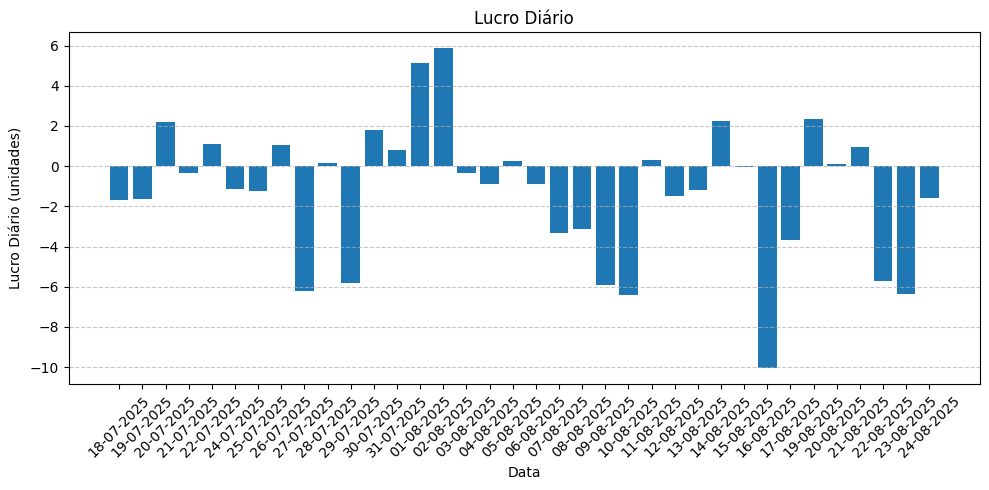

In [6]:
import matplotlib.pyplot as plt

# Extrai os pares (data, lucro)
dados = [(item["Data"], item["Lucro Diário (unidades)"]) for item in estatisticas_geral]

# Ordena os dados pela data convertida
dados_ordenados = sorted(dados, key=lambda x: datetime.strptime(x[0], "%d-%m-%Y"))

# Separa as listas ordenadas
datas_ordenadas = [data for data, _ in dados_ordenados]
lucros_ordenados = [lucro for _, lucro in dados_ordenados]

# Cria o gráfico
plt.figure(figsize=(10, 5))
plt.bar(datas_ordenadas, lucros_ordenados)
plt.xlabel("Data")
plt.ylabel("Lucro Diário (unidades)")
plt.title("Lucro Diário")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [7]:
estatisticas = {
    "Total de Jogos": len(df),
    "Total de Vitórias": (df['Gols_Home'] > df['Gols_Away']).sum(),
    "Total de Derrotas": len(df) - (df['Gols_Home'] > df['Gols_Away']).sum(),
    "Taxa Mínima de Acerto (%)": round((1 / df['Odd_Home'].mean()) * 100, 2),
    "Taxa de Vitórias (%)": round(((df['Gols_Home'] > df['Gols_Away']).sum() / len(df)) * 100, 2),
    "Odd Média": round(df['Odd_Home'].mean(), 2),
    "Lucro Total (unidades)": round(df['Lucro'].sum(), 2),
    "ROI (%)": round((df['Lucro'].sum() / len(df)) * 100, 2),   
}


print("📊 RESUMO FINAL 📊")
for chave, valor in estatisticas.items():
    print(f"{chave}: {valor}")

📊 RESUMO FINAL 📊
Total de Jogos: 929
Total de Vitórias: 605
Total de Derrotas: 324
Taxa Mínima de Acerto (%): 68.2
Taxa de Vitórias (%): 65.12
Odd Média: 1.47
Lucro Total (unidades): -44.76
ROI (%): -4.82


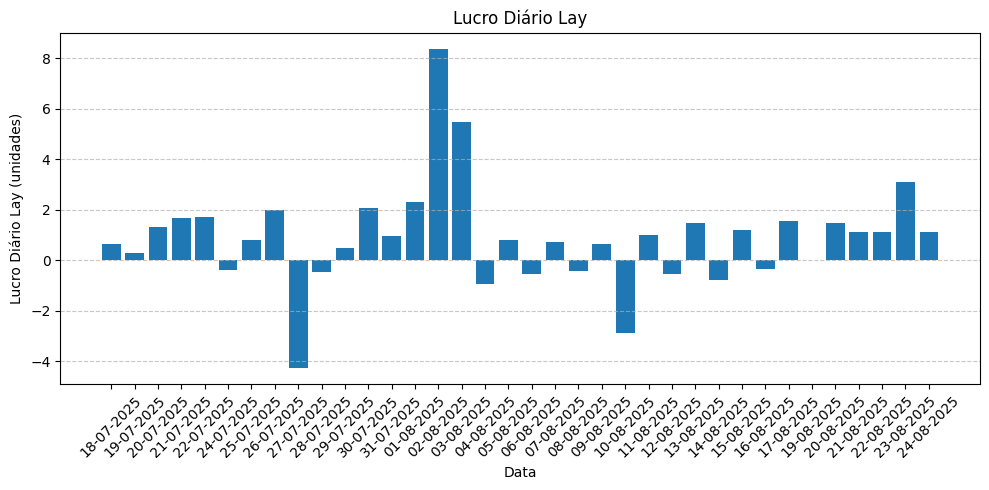

In [8]:
# Extrai os pares (data, lucro)
dados = [(item["Data"], item["Lucro Diário Lay (unidades)"]) for item in estatisticas_geral]

# Ordena os dados pela data convertida
dados_ordenados = sorted(dados, key=lambda x: datetime.strptime(x[0], "%d-%m-%Y"))

# Separa as listas ordenadas
datas_ordenadas = [data for data, _ in dados_ordenados]
#lucros_ordenados = [lucro for _, lucro in dados_ordenados]
lucros_ordenados = [round(float(lucro), 2) for _, lucro in dados_ordenados]

# Cria o gráfico
plt.figure(figsize=(10, 5))
plt.bar(datas_ordenadas, lucros_ordenados)
plt.xlabel("Data")
plt.ylabel("Lucro Diário Lay (unidades)")
plt.title("Lucro Diário Lay")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [9]:
vitorias = (df['Gols_Home'] > df['Gols_Away']).sum()
empates = (df['Gols_Home'] == df['Gols_Away']).sum()
acertos = vitorias + empates
odd_media_lay = df['Odd_Away'].mean()
odd_back_equivalente = round(1 + (1 / (odd_media_lay -1)), 2)

estatisticas = {
    "Total de Jogos": len(df),
    "Total de Acertos": acertos,
    "Total de Derrotas": len(df) - acertos,
    "Taxa Mínima de Acerto (%)": round((1 / odd_back_equivalente) * 100, 2),
    "Taxa de Acertos  (%)": round((acertos / len(df)) * 100, 2),
    "Odd Média": round(odd_media_lay, 2),
    "Lucro Total (unidades)": round(df['Lucro_Lay'].sum(), 2),
    "ROI (%)": round((df['Lucro_Lay'].sum() / len(df)) * 100, 2),
    "Odd Back Equivalente": odd_back_equivalente
}
print("📊 RESUMO FINAL 📊")
for chave, valor in estatisticas.items():
    print(f"{chave}: {valor}")

📊 RESUMO FINAL 📊
Total de Jogos: 929
Total de Acertos: 792
Total de Derrotas: 137
Taxa Mínima de Acerto (%): 83.33
Taxa de Acertos  (%): 85.25
Odd Média: 5.96
Lucro Total (unidades): 31.72
ROI (%): 3.41
Odd Back Equivalente: 1.2


In [10]:
dados_ordenados

[('18-07-2025', 0.63),
 ('19-07-2025', 0.3),
 ('20-07-2025', 1.33),
 ('21-07-2025', 1.66),
 ('22-07-2025', 1.69),
 ('24-07-2025', -0.4),
 ('25-07-2025', 0.8),
 ('26-07-2025', 1.98),
 ('27-07-2025', -4.28),
 ('28-07-2025', -0.48),
 ('29-07-2025', 0.47),
 ('30-07-2025', 2.05),
 ('31-07-2025', 0.97),
 ('01-08-2025', 2.31),
 ('02-08-2025', 8.37),
 ('03-08-2025', 5.46),
 ('04-08-2025', -0.93),
 ('05-08-2025', 0.81),
 ('06-08-2025', -0.54),
 ('07-08-2025', 0.7),
 ('08-08-2025', -0.43),
 ('09-08-2025', 0.62),
 ('10-08-2025', -2.89),
 ('11-08-2025', 0.99),
 ('12-08-2025', -0.53),
 ('13-08-2025', 1.48),
 ('14-08-2025', -0.78),
 ('15-08-2025', 1.21),
 ('16-08-2025', -0.35),
 ('17-08-2025', 1.56),
 ('19-08-2025', 0.01),
 ('20-08-2025', 1.49),
 ('21-08-2025', 1.1),
 ('22-08-2025', 1.12),
 ('23-08-2025', 3.09),
 ('24-08-2025', 1.13)]

In [11]:
1 / 4

0.25

In [12]:
df_dados_ordenados = pd.DataFrame(dados_ordenados, columns=['Data', 'Valor'])
df_dados_ordenados['Data'] = pd.to_datetime(df_dados_ordenados['Data'], format='%d-%m-%Y')
df_dados_ordenados = df_dados_ordenados.sort_values(by='Data').reset_index(drop=True)

In [13]:
df_dados_ordenados

,Data,Valor
0,2025-07-18,0.63
1,2025-07-19,0.30
2,2025-07-20,1.33
3,2025-07-21,1.66
4,2025-07-22,1.69
5,2025-07-24,-0.40
6,2025-07-25,0.80
7,2025-07-26,1.98
8,2025-07-27,-4.28
9,2025-07-28,-0.48


In [14]:
df_dados_ordenados.describe()

,Data,Valor
count,36,36.00
mean,2025-08-05 12:40:00,0.88
min,2025-07-18 00:00:00,-4.28
25%,2025-07-27 18:00:00,-0.36
50%,2025-08-05 12:00:00,0.89
75%,2025-08-14 06:00:00,1.51
max,2025-08-24 00:00:00,8.37
std,NaN,2.06


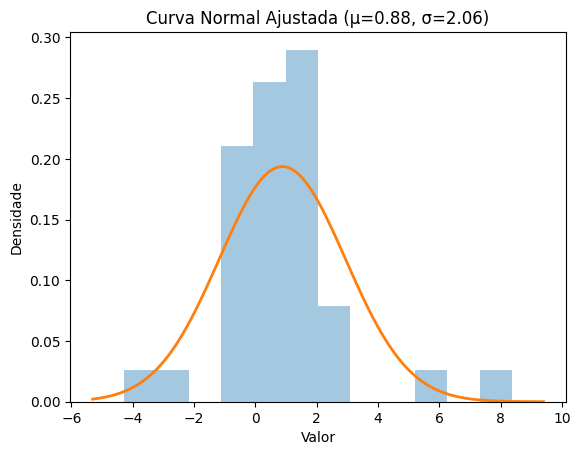

In [15]:
# Série de dados
vals = df_dados_ordenados['Valor'].to_numpy()

# Parâmetros da normal (amostral)
mu = vals.mean()
sigma = vals.std(ddof=1)

# Eixo x para a curva
x = np.linspace(vals.min() - 0.5*sigma, vals.max() + 0.5*sigma, 400)

# PDF da Normal N(mu, sigma^2)
pdf = (1 / (sigma * np.sqrt(2*np.pi))) * np.exp(-0.5 * ((x - mu)/sigma)**2)

# Histograma normalizado + curva normal
plt.figure()
plt.hist(vals, bins='auto', density=True, alpha=0.4)
plt.plot(x, pdf, linewidth=2)
plt.title(f'Curva Normal Ajustada (μ={mu:.2f}, σ={sigma:.2f})')
plt.xlabel('Valor')
plt.ylabel('Densidade')
plt.show()


In [16]:
import numpy as np

valores = [0.63, 0.3, 1.33, 1.66, 1.69, -0.4, 0.8, 1.98, -4.28, -0.48, 0.47, 2.05, 0.97, 2.31, 8.37]

# Variância populacional
var_pop = np.var(valores)

# Variância amostral
var_amostra = np.var(valores, ddof=1)

print(f"Variância populacional: {var_pop:.4f}")
print(f"Variância amostral: {var_amostra:.4f}")


Variância populacional: 6.1140
Variância amostral: 6.5507


In [17]:
df_lucro_por_operacao = df[["Lucro_Lay"]]

In [18]:
df_lucro_por_operacao.describe()

,Lucro_Lay
count,929.00
mean,0.03
std,0.43
min,-1.00
25%,0.15
50%,0.20
75%,0.24
max,0.44


In [19]:
df_lucro_por_operacao.to_csv("./dados/lucro_por_operacao.csv", index=False)